# Experiment 2: multimodal spherical mixture and kernel-risk calibration


This notebook reproduces Experiment 2 from the paper: a multimodal von Mises--Fisher mixture on the sphere and calibration of kernel ESS against empirical MMD error.

Set `RUN_FULL_EXPERIMENT = True` to use the manuscript settings.  The default `False` setting runs a smaller version for a quick check.


In [1]:

# Choose whether to run the full manuscript experiment or a simplified quick version.
RUN_FULL_EXPERIMENT = False

# Re-run the simulation even if output files already exist.
# Set this to False to only reload existing outputs.
RERUN_SIMULATION = True

# Save figures in these formats.
FIGURE_FORMATS = ("png", "pdf")


In [2]:

from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "src.py").exists() and (ROOT.parent / "src.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import src

mode = "full" if RUN_FULL_EXPERIMENT else "quick"
outdir = ROOT / "outputs" / f"exp2_{mode}"
figdir = ROOT / "figures" / f"exp2_{mode}"
outdir.mkdir(parents=True, exist_ok=True)
figdir.mkdir(parents=True, exist_ok=True)
print(f"Repository root: {ROOT}")
print(f"Output directory: {outdir}")


Repository root: /mnt/data/IntrinsicESS_publication
Output directory: /mnt/data/IntrinsicESS_publication/outputs/exp2_quick



## Experiment settings

The full settings match the manuscript: 20 replications, 2500 retained draws per chain, and an iid reference sample of size 8000.


In [3]:

if RUN_FULL_EXPERIMENT:
    settings = dict(
        seed=20260202,
        burn=1000,
        n_keep=2500,
        n_rep=20,
        ref_n=8000,
        rhos=(0.35, 0.60, 0.85),
        local_proposal_kappa=90.0,
        independence_proposal_kappa=12.0,
        save_reference=True,
    )
else:
    settings = dict(
        seed=20260202,
        burn=200,
        n_keep=500,
        n_rep=4,
        ref_n=1000,
        rhos=(0.35, 0.60, 0.85),
        local_proposal_kappa=90.0,
        independence_proposal_kappa=12.0,
        save_reference=True,
    )
settings


{'seed': 20260202,
 'burn': 200,
 'n_keep': 500,
 'n_rep': 4,
 'ref_n': 1000,
 'rhos': (0.35, 0.6, 0.85),
 'local_proposal_kappa': 90.0,
 'independence_proposal_kappa': 12.0,
 'save_reference': True}


## Run or load the experiment


In [4]:

needed = [outdir / "exp2_results.csv", outdir / "exp2_config_summary.json"]
if RERUN_SIMULATION or not all(p.exists() for p in needed):
    config = src.run_spherical_mixture_experiment(outdir=outdir, **settings)
else:
    config = src.load_json(outdir / "exp2_config_summary.json")
config


{'experiment': 'exp2_spherical_mixture',
 'seed': 20260202,
 'burn': 200,
 'n_keep': 500,
 'n_rep': 4,
 'ref_n': 1000,
 'rhos': [0.35, 0.6, 0.85],
 'bandwidth': 10,
 'local_proposal_kappa': 90.0,
 'independence_proposal_kappa': 12.0,
 'target_mus': [[0.5773502691896258, 0.5773502691896258, 0.5773502691896258],
  [0.5773502691896258, -0.5773502691896258, -0.5773502691896258],
  [-0.5773502691896258, 0.5773502691896258, -0.5773502691896258],
  [-0.5773502691896258, -0.5773502691896258, 0.5773502691896258]],
 'target_kappas': [28.0, 28.0, 28.0, 28.0],
 'target_weights': [0.4000000000000001,
  0.30000000000000004,
  0.20000000000000004,
  0.10000000000000002],
 'reference_nearest_mode_probs': [0.387, 0.326, 0.192, 0.095],
 'reference_terms': {'0.35': {'Kyy_mean': 1.0483059798571148,
   'gamma0_ref': 0.4906462048092326},
  '0.6': {'Kyy_mean': 1.1693133221913294, 'gamma0_ref': 1.3320186965051757},
  '0.85': {'Kyy_mean': 1.484654472250808, 'gamma0_ref': 5.187199393809668}}}


## Summary table

The table below summarizes kernel ESS, estimated long-run risk constants, corrected empirical MMD error, calibration ratios, mode-frequency total variation error, and acceptance rates.


In [5]:

raw_df, summary_df, config = src.summarize_spherical_mixture_experiment(outdir)
summary_df.round(4)


,sampler,rho,kernel_ess_mean,kernel_ess_sd,sigma2_mean,sigma2_sd,n_mmd_mean,n_mmd_sd,ratio_mean,ratio_sd,mode_tv_mean,mode_tv_sd,accept_mean,accept_sd
0,independence_mixture,0.35,191.8689,8.5430,1.2745,0.0282,1.8368,1.2673,1.4457,1.0169,0.0550,0.0276,0.5089,0.0210
1,independence_mixture,0.60,191.0496,9.2089,3.4765,0.0939,4.8875,2.6398,1.4057,0.7714,0.0550,0.0276,0.5089,0.0210
2,independence_mixture,0.85,186.5050,10.1995,13.8568,0.5454,19.4472,7.5231,1.3991,0.5316,0.0550,0.0276,0.5089,0.0210
3,local_vmf,0.35,65.3418,4.4518,0.6166,0.1246,260.5672,78.9304,440.9650,175.8239,0.7895,0.1334,0.7261,0.0124
4,local_vmf,0.60,70.8092,5.2415,2.9743,0.5287,582.5980,178.3782,203.3647,80.5280,0.7895,0.1334,0.7261,0.0124
5,local_vmf,0.85,96.4531,8.7392,17.5181,2.4513,1178.5944,368.3260,69.2890,26.9628,0.7895,0.1334,0.7261,0.0124



## Reference mode probabilities


In [6]:

pd.read_csv(outdir / "exp2_reference_mode_probs.csv")


,component,reference_nearest_mode_probability,nominal_mixture_weight
0,0,0.387,0.4
1,1,0.326,0.3
2,2,0.192,0.2
3,3,0.095,0.1



## Figures

Figure 2 compares intrinsic kernel ESS and mode-frequency error.  Figure 3 compares corrected empirical MMD risk constants with the estimated long-run risk constants.


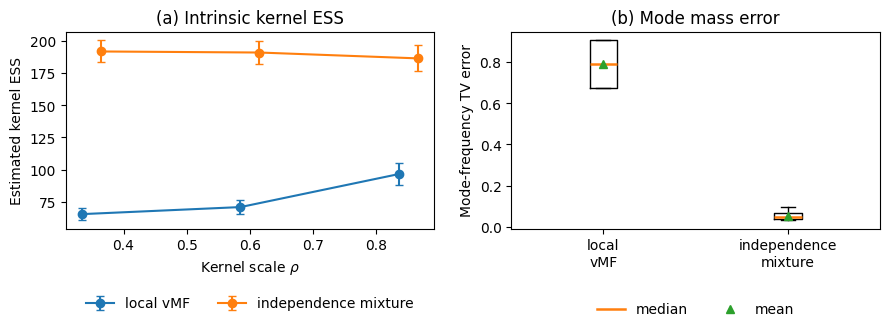

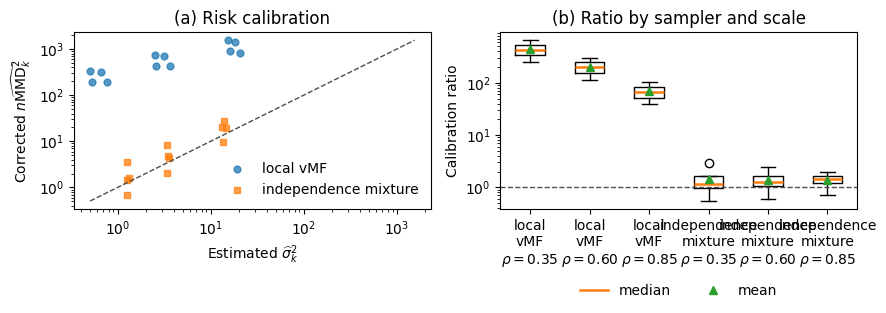

Saved figures to /mnt/data/IntrinsicESS_publication/figures/exp2_quick


In [7]:

src.plot_spherical_mixture_experiment(outdir, figdir, formats=FIGURE_FORMATS)
for name in ["fig2.png", "fig3.png"]:
    display(Image(filename=str(figdir / name)))
print(f"Saved figures to {figdir}")



## Output files


In [8]:

for p in sorted(outdir.glob("*")):
    print(p.relative_to(ROOT))
for p in sorted(figdir.glob("fig*.*")):
    print(p.relative_to(ROOT))


outputs/exp2_quick/exp2_config_summary.json
outputs/exp2_quick/exp2_mode_frequencies.csv
outputs/exp2_quick/exp2_reference_mode_probs.csv
outputs/exp2_quick/exp2_reference_sample.npz
outputs/exp2_quick/exp2_results.csv
figures/exp2_quick/fig2.pdf
figures/exp2_quick/fig2.png
figures/exp2_quick/fig3.pdf
figures/exp2_quick/fig3.png
